# Evaluación Sumativa – Fase 2
## MCDI501: Estadística Computacional para la Toma de Decisiones
### Análisis Exploratorio e Inferencial: Bank Marketing Dataset

**Integrantes:**
- José Miguel Serrano
- Jesús Fernández Urbaneja
- Osvaldo Rodrigo Moncada Peralta
- Evelyn Andrea Andrade Cárdenas

**Docente:** Jean Paul Maidana González  
**Fecha:** 25/06/2026  
**Dataset:** Bank Marketing – UCI Machine Learning Repository (`bank.csv`)  
**Repositorio:** https://github.com/leofer23/formativa1-bank-marketing

---

### Índice
1. [Preparación y carga de datos](#1)
2. [Reporte de calidad de datos](#2)
3. [Estadística descriptiva univariada](#3)
4. [Análisis bivariado](#4)
5. [Estimación puntual e intervalos de confianza](#5)
6. [Pruebas de hipótesis](#6)
7. [Interpretación y próximos pasos](#7)


## 1. Preparación y carga de datos <a id='1'></a>

In [2]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})
COLOR_SI  = '#1a6ea8'
COLOR_NO  = '#c0392b'
COLOR_NEU = '#2c3e50'

print('Librerías cargadas correctamente.')
print(f'  numpy     {np.__version__}')
print(f'  pandas    {pd.__version__}')
import scipy; print(f'  scipy     {scipy.__version__}')


Librerías cargadas correctamente.
  numpy     2.4.6
  pandas    3.0.3
  scipy     1.18.0


In [3]:
# Carga del dataset
# NOTA: coloque bank.csv en el mismo directorio que este notebook
df = pd.read_csv('bank.csv', sep=';')

print(f'Dataset cargado exitosamente')
print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(5)


Dataset cargado exitosamente
Dimensiones: 4,521 filas × 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
# Tipos de datos por variable
print('Tipos de datos y conteo de no-nulos:')
df.info()


Tipos de datos y conteo de no-nulos:
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


## 2. Reporte de calidad de datos <a id='2'></a>

Se verifica la integridad del dataset antes de cualquier análisis estadístico.

In [5]:
# 2.1 Valores nulos
nulos = df.isnull().sum()
print('=== Valores nulos por variable ===')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos ✓')

# 2.2 Duplicados
dupl = df.duplicated().sum()
print(f'\nRegistros duplicados: {dupl} ✓' if dupl == 0 else f'Duplicados encontrados: {dupl}')

# 2.3 Resumen de calidad
print('\n=== Resumen de calidad ===')
reporte = pd.DataFrame({
    'Tipo': df.dtypes,
    'No nulos': df.notna().sum(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum()/len(df)*100).round(2),
    'Únicos': df.nunique()
})
print(reporte.to_string())


=== Valores nulos por variable ===
Sin valores nulos ✓

Registros duplicados: 0 ✓

=== Resumen de calidad ===
            Tipo  No nulos  Nulos  % Nulos  Únicos
age        int64      4521      0      0.0      67
job          str      4521      0      0.0      12
marital      str      4521      0      0.0       3
education    str      4521      0      0.0       4
default      str      4521      0      0.0       2
balance    int64      4521      0      0.0    2353
housing      str      4521      0      0.0       2
loan         str      4521      0      0.0       2
contact      str      4521      0      0.0       3
day        int64      4521      0      0.0      31
month        str      4521      0      0.0      12
duration   int64      4521      0      0.0     875
campaign   int64      4521      0      0.0      32
pdays      int64      4521      0      0.0     292
previous   int64      4521      0      0.0      24
poutcome     str      4521      0      0.0       4
y            str      4

In [6]:
# 2.4 Verificación de rangos y consistencia
print('=== Verificación de rangos ===')
print(f'age:      [{df.age.min()}, {df.age.max()}]  (esperado: 18-100)')
print(f'balance:  [{df.balance.min():,}, {df.balance.max():,}]  (puede ser negativo: OK)')
print(f'duration: [{df.duration.min()}, {df.duration.max()}] seg')
print(f'campaign: [{df.campaign.min()}, {df.campaign.max()}]')
print(f'pdays:    [{df.pdays.min()}, {df.pdays.max()}]  (-1 = sin contacto previo)')

# Valores 'unknown' por variable categórica
cat_vars = ['job','marital','education','contact','poutcome']
print('\n=== Valores unknown por variable categórica ===')
for v in cat_vars:
    n_unk = (df[v]=='unknown').sum()
    pct   = n_unk/len(df)*100
    print(f'  {v:<12}: {n_unk:>4} ({pct:.1f}%)')

print('\nDecisión: se mantienen los \'unknown\' como categoría válida.')
print('El dataset no requiere limpieza adicional — no hay nulos ni duplicados.')


=== Verificación de rangos ===
age:      [19, 87]  (esperado: 18-100)
balance:  [-3,313, 71,188]  (puede ser negativo: OK)
duration: [4, 3025] seg
campaign: [1, 50]
pdays:    [-1, 871]  (-1 = sin contacto previo)

=== Valores unknown por variable categórica ===
  job         :   38 (0.8%)
  marital     :    0 (0.0%)
  education   :  187 (4.1%)
  contact     : 1324 (29.3%)
  poutcome    : 3705 (82.0%)

Decisión: se mantienen los 'unknown' como categoría válida.
El dataset no requiere limpieza adicional — no hay nulos ni duplicados.


### Conclusión de calidad
El dataset `bank.csv` presenta:
- **0 valores nulos** en las 17 variables
- **0 registros duplicados**
- **Rangos coherentes** en todas las variables numéricas
- **Valores 'unknown'** en variables categóricas (job, contact, poutcome) tratados como categoría válida
- `pdays = -1` codifica ausencia de contacto previo (82.0% de los registros) — se documenta y trata adecuadamente en el análisis


## 3. Estadística descriptiva univariada <a id='3'></a>

**(ID1.2)** Aplicamos medidas de tendencia central, dispersión y representaciones gráficas adecuadas al tipo de cada variable.

In [7]:
# 3.1 Variables numéricas: resumen estadístico completo
num_vars = ['age','balance','duration','campaign','pdays','previous']

desc = df[num_vars].describe().T
desc['cv (%)']  = (desc['std'] / desc['mean'].abs() * 100).round(1)
desc['mediana'] = df[num_vars].median()
desc['moda']    = df[num_vars].mode().iloc[0]
desc['asimetria'] = df[num_vars].skew().round(3)
desc['curtosis']  = df[num_vars].kurt().round(3)

cols_show = ['count','mean','mediana','moda','std','cv (%)','min','max','asimetria','curtosis']
print('Tabla de estadística descriptiva – Variables Numéricas')
print(desc[cols_show].round(3).to_string())


Tabla de estadística descriptiva – Variables Numéricas
           count      mean  mediana  moda       std  cv (%)     min      max  asimetria  curtosis
age       4521.0    41.170     39.0    34    10.576    25.7    19.0     87.0      0.700     0.349
balance   4521.0  1422.658    444.0     0  3009.638   211.6 -3313.0  71188.0      6.596    88.390
duration  4521.0   263.961    185.0   123   259.857    98.4     4.0   3025.0      2.772    12.530
campaign  4521.0     2.794      2.0     1     3.110   111.3     1.0     50.0      4.744    37.169
pdays     4521.0    39.767     -1.0    -1   100.121   251.8    -1.0    871.0      2.717     7.957
previous  4521.0     0.543      0.0     0     1.694   312.1     0.0     25.0      5.875    51.995


> ⚠️ **Nota sobre `duration`:** Esta variable registra la duración de la última llamada 
> telefónica en segundos. Se incluye aquí con fines descriptivos, pero **no puede usarse 
> como variable predictora** en modelos futuros, ya que su valor solo se conoce al 
> finalizar la llamada, es decir, *después* de que el resultado (suscripción o no) 
> ya ocurrió. Usarla como predictor introduciría fuga de datos (*data leakage*). 
> Para modelado predictivo se debe excluir del conjunto de features.

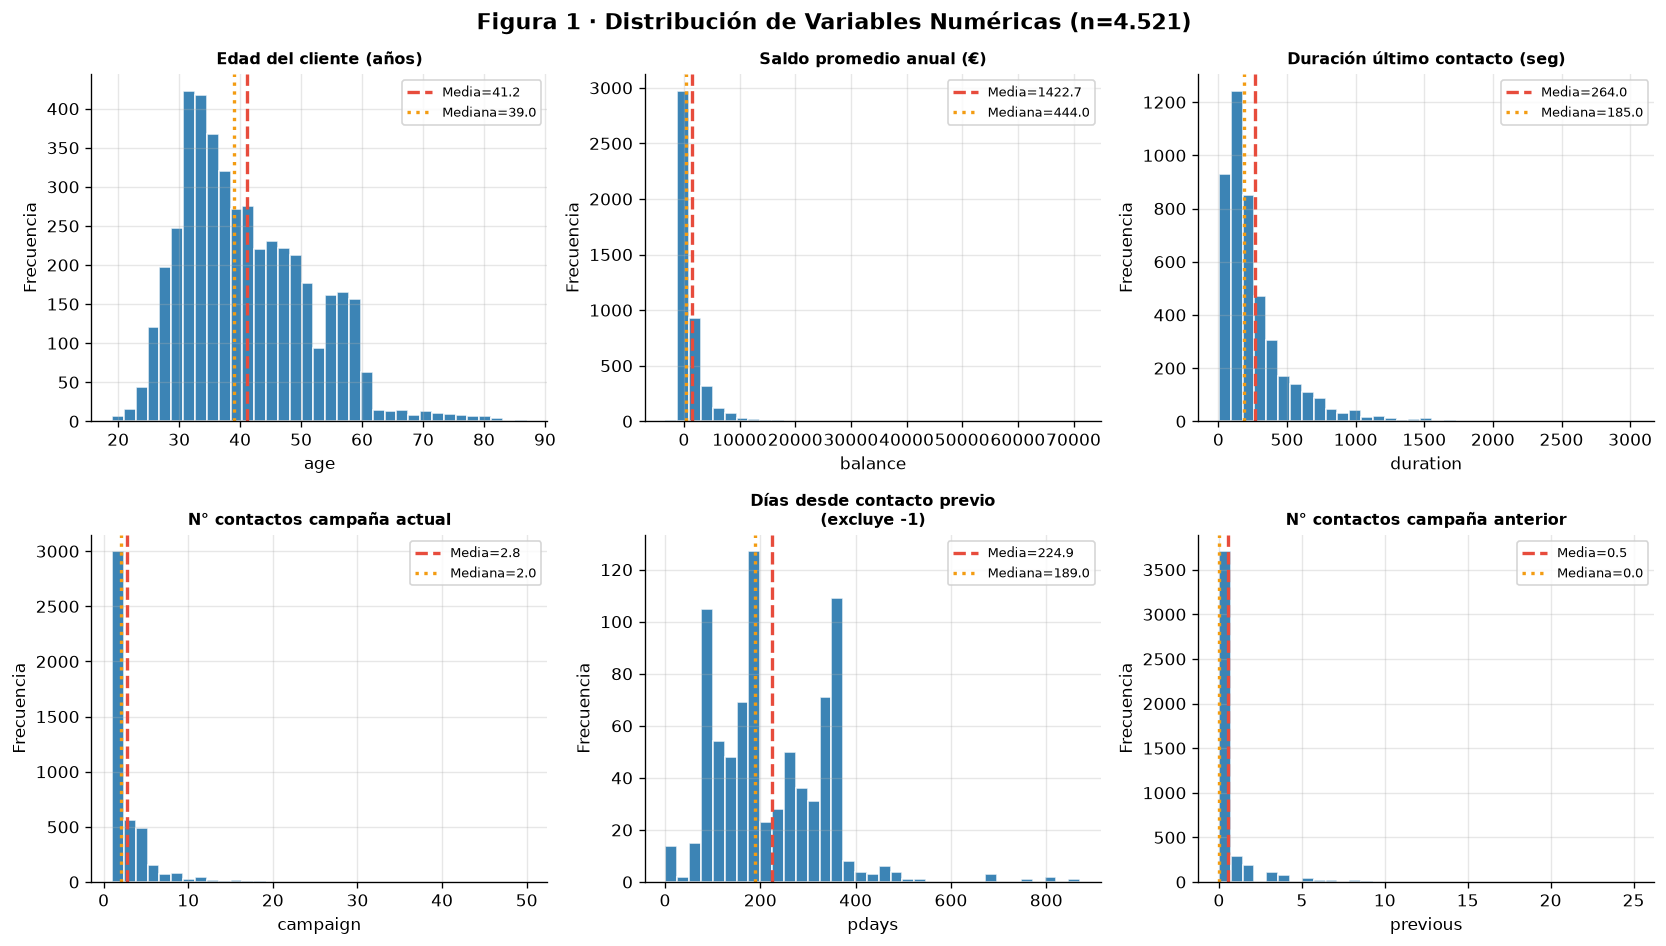

In [8]:
# 3.2 Histogramas con media y mediana
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
titles = {
    'age':      'Edad del cliente (años)',
    'balance':  'Saldo promedio anual (€)',
    'duration': 'Duración último contacto (seg)',
    'campaign': 'N° contactos campaña actual',
    'pdays':    'Días desde contacto previo\n(excluye -1)',
    'previous': 'N° contactos campaña anterior'
}
for i, var in enumerate(num_vars):
    data = df[df[var] != -1][var] if var == 'pdays' else df[var]
    axes[i].hist(data, bins=35, color=COLOR_SI, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='#e74c3c', lw=2, ls='--', label=f'Media={data.mean():.1f}')
    axes[i].axvline(data.median(), color='#f39c12', lw=2, ls=':',  label=f'Mediana={data.median():.1f}')
    axes[i].set_title(titles[var], fontsize=9.5, fontweight='bold')
    axes[i].set_xlabel(var); axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=7.5)
fig.suptitle('Figura 1 · Distribución de Variables Numéricas (n=4.521)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# 3.3 Variables categóricas: frecuencias absolutas y relativas
cat_vars = ['job','marital','education','default','housing','loan','contact','poutcome','y']

for v in cat_vars:
    abs_freq = df[v].value_counts()
    rel_freq = df[v].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({'Frec. Absoluta': abs_freq, 'Frec. Relativa (%)': rel_freq})
    print(f'\n--- {v.upper()} ---')
    print(tabla.to_string())



--- JOB ---
               Frec. Absoluta  Frec. Relativa (%)
job                                              
management                969               21.43
blue-collar               946               20.92
technician                768               16.99
admin.                    478               10.57
services                  417                9.22
retired                   230                5.09
self-employed             183                4.05
entrepreneur              168                3.72
unemployed                128                2.83
housemaid                 112                2.48
student                    84                1.86
unknown                    38                0.84

--- MARITAL ---
          Frec. Absoluta  Frec. Relativa (%)
marital                                     
married             2797               61.87
single              1196               26.45
divorced             528               11.68

--- EDUCATION ---
           Frec. Absoluta 

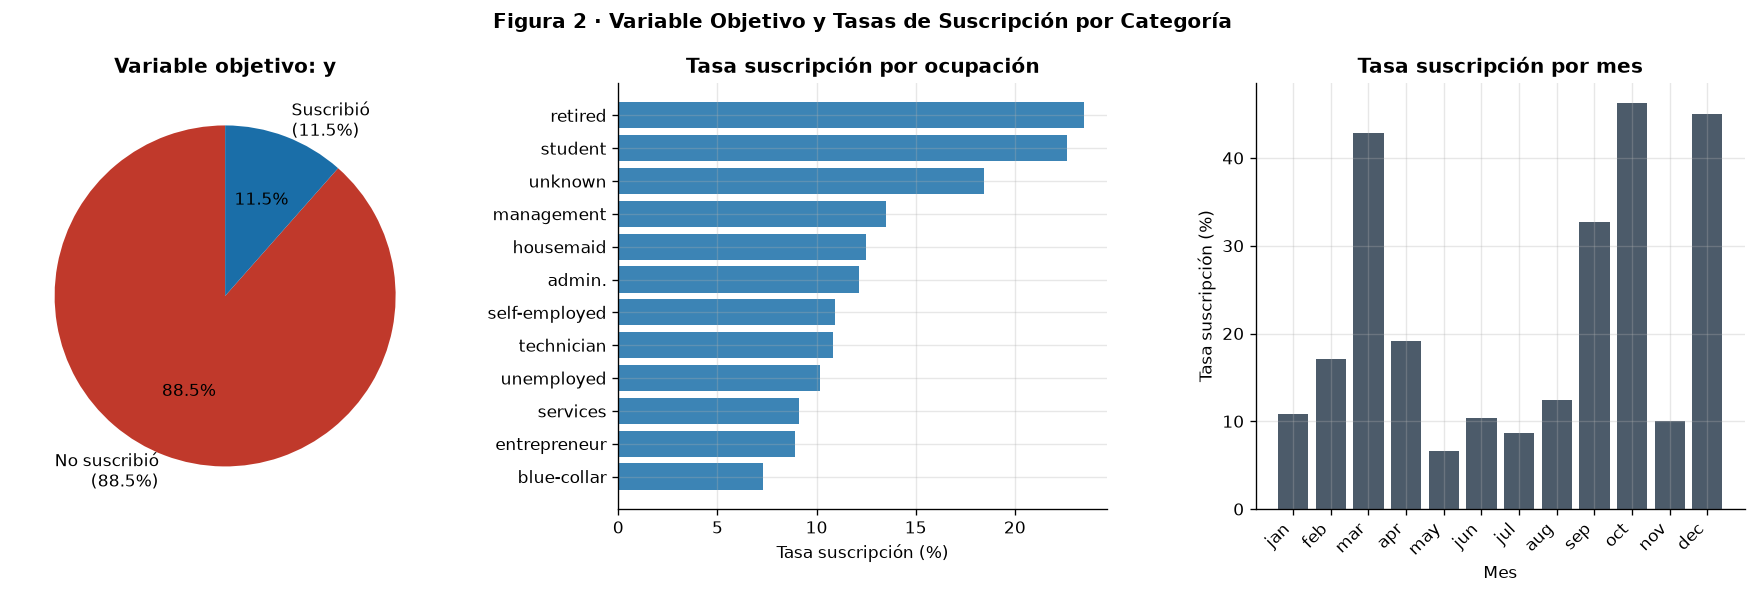

In [10]:
# 3.4 Gráficos variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie variable objetivo
counts_y = df['y'].value_counts()
axes[0].pie(counts_y, labels=['No suscribió\n(88.5%)','Suscribió\n(11.5%)'],
            colors=[COLOR_NO, COLOR_SI], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[0].set_title('Variable objetivo: y', fontweight='bold')

# Barras por job
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
axes[1].barh(job_rate.index, job_rate.values, color=COLOR_SI, alpha=0.85)
axes[1].set_xlabel('Tasa suscripción (%)')
axes[1].set_title('Tasa suscripción por ocupación', fontweight='bold')

# Barras por mes
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100)
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
axes[2].bar(month_rate.index, month_rate.values, color=COLOR_NEU, alpha=0.85)
axes[2].set_xlabel('Mes'); axes[2].set_ylabel('Tasa suscripción (%)')
axes[2].set_title('Tasa suscripción por mes', fontweight='bold')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Figura 2 · Variable Objetivo y Tasas de Suscripción por Categoría',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


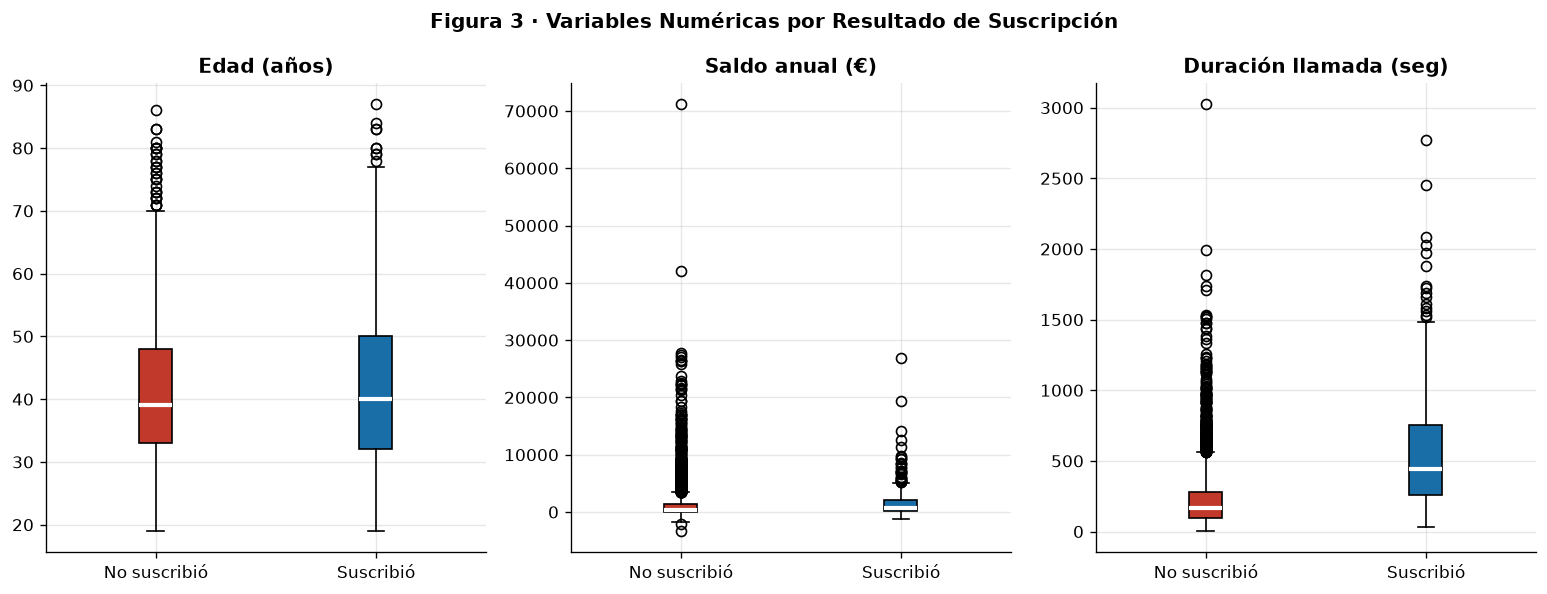

In [11]:
# 3.5 Boxplots por resultado de suscripción
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for i, (var, title) in enumerate(zip(
        ['age','balance','duration'],
        ['Edad (años)','Saldo anual (€)','Duración llamada (seg)'])):
    d_yes = df[df['y']=='yes'][var]
    d_no  = df[df['y']=='no'][var]
    bp = axes[i].boxplot([d_no, d_yes], patch_artist=True,
                          tick_labels=['No suscribió','Suscribió'],
                          medianprops=dict(color='white', lw=2.5))
    bp['boxes'][0].set_facecolor(COLOR_NO)
    bp['boxes'][1].set_facecolor(COLOR_SI)
    axes[i].set_title(title, fontweight='bold')
fig.suptitle('Figura 3 · Variables Numéricas por Resultado de Suscripción',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Análisis bivariado <a id='4'></a>

Se identifican relaciones entre variables de interés y la variable objetivo `y`, apoyándonos en correlaciones y visualizaciones.

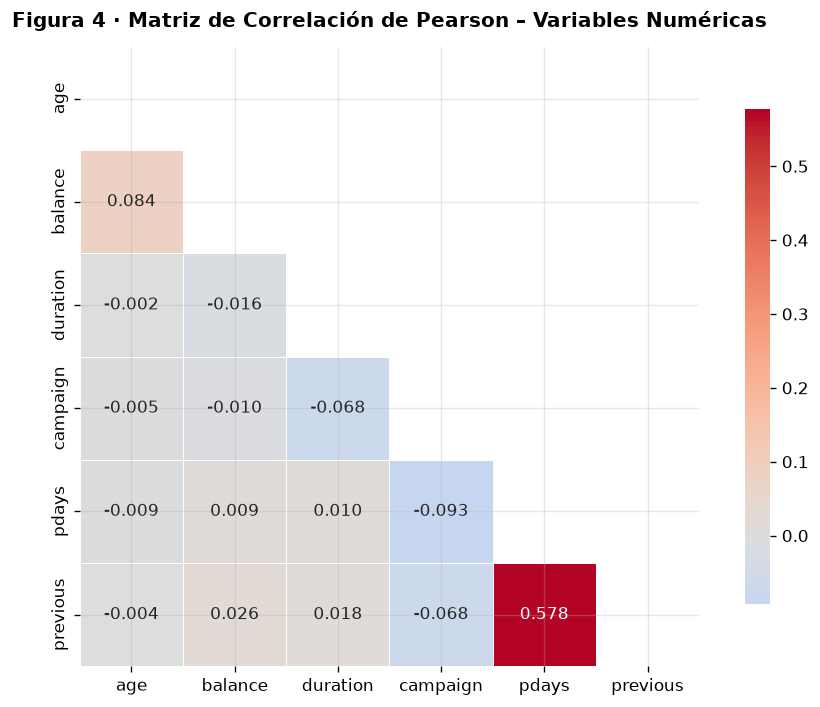

Correlaciones relevantes:
  pdays – previous  : r = 0.578  (moderada positiva)
  age   – balance   : r = 0.084  (débil positiva)
  campaign – duration: r = -0.068  (débil negativa)


In [12]:
# 4.1 Matriz de correlaciones – variables numéricas
fig, ax = plt.subplots(figsize=(8, 6))
num_corr = ['age','balance','duration','campaign','pdays','previous']
corr_m = df[num_corr].corr()
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8}, annot_kws={'size':10})
ax.set_title('Figura 4 · Matriz de Correlación de Pearson – Variables Numéricas',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig4_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlaciones relevantes:')
print(f'  pdays – previous  : r = {corr_m.loc["pdays","previous"]:.3f}  (moderada positiva)')
print(f'  age   – balance   : r = {corr_m.loc["age","balance"]:.3f}  (débil positiva)')
print(f'  campaign – duration: r = {corr_m.loc["campaign","duration"]:.3f}  (débil negativa)')


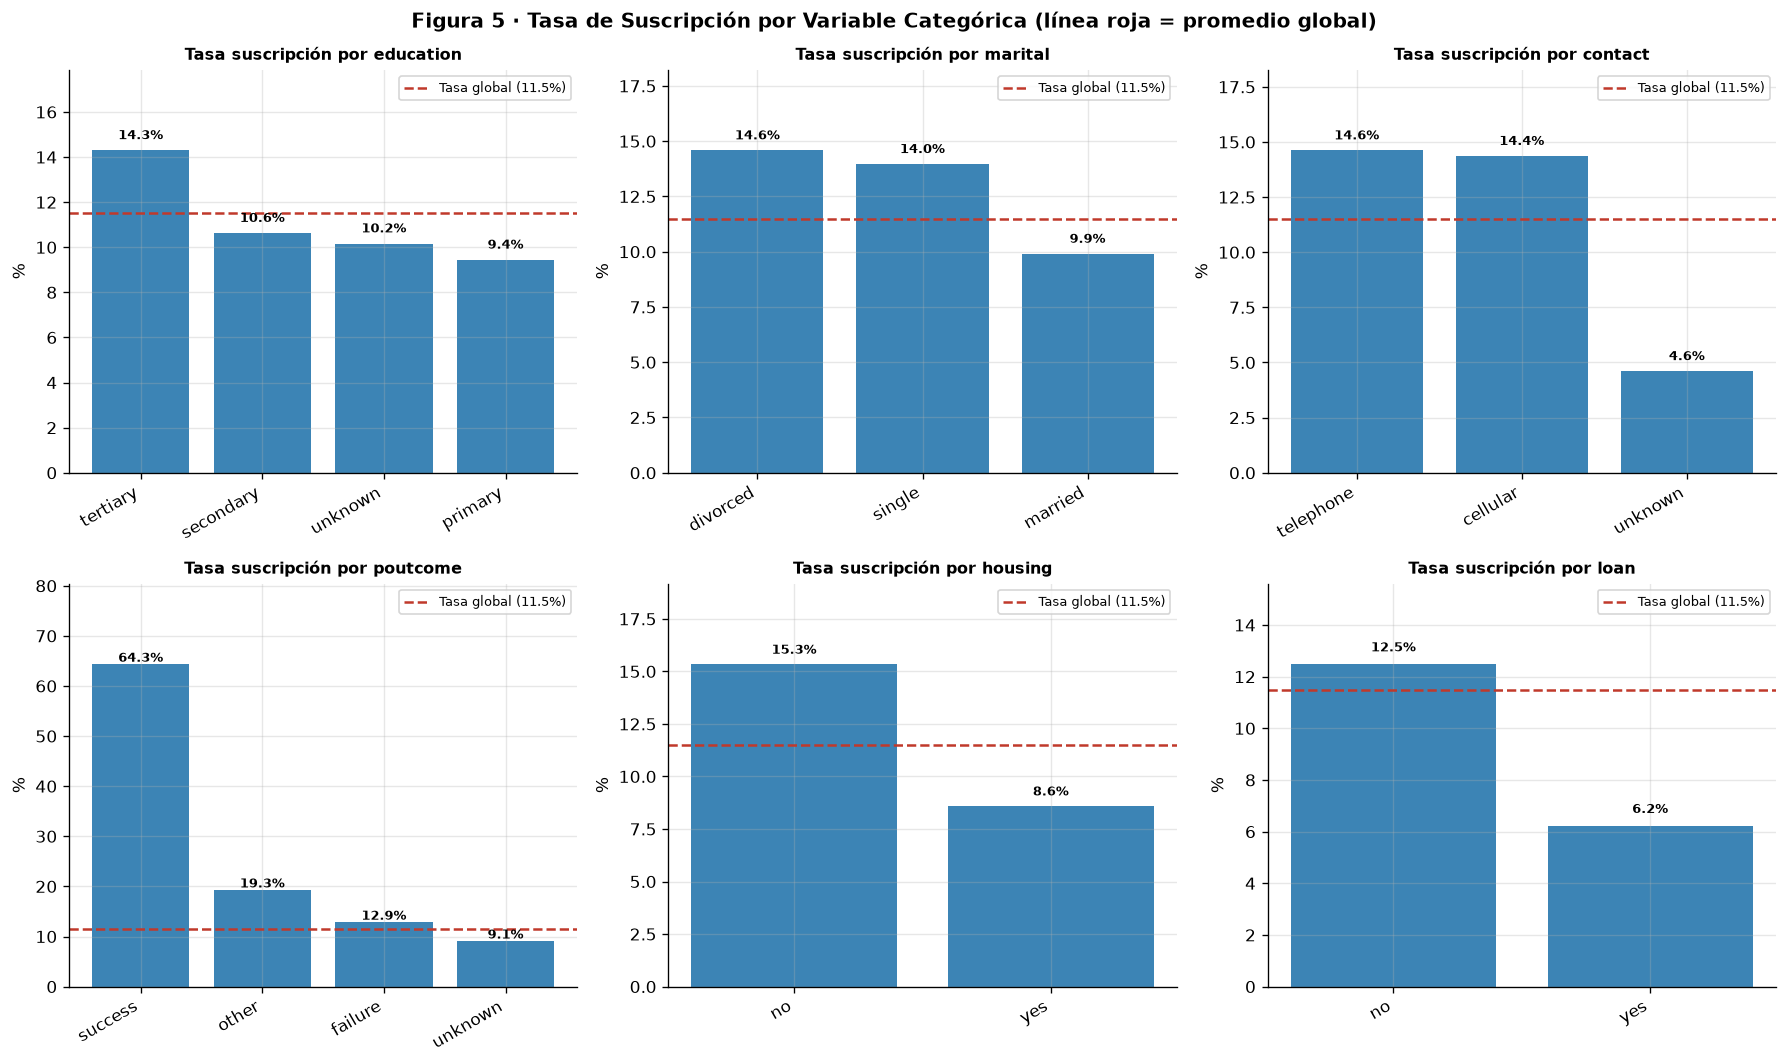

In [13]:
# 4.2 Tasa de suscripción por variables categóricas
cat_bivariado = ['education','marital','contact','poutcome','housing','loan']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(cat_bivariado):
    rate = df.groupby(var)['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
    bars = axes[i].bar(rate.index, rate.values, color=COLOR_SI, alpha=0.85)
    axes[i].axhline(11.5, color=COLOR_NO, lw=1.5, ls='--', label='Tasa global (11.5%)')
    axes[i].set_title(f'Tasa suscripción por {var}', fontweight='bold', fontsize=9.5)
    axes[i].set_ylabel('%'); axes[i].set_ylim(0, max(rate.values)*1.25)
    axes[i].legend(fontsize=7.5)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.1f}%', ha='center', fontsize=7.5, fontweight='bold')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Figura 5 · Tasa de Suscripción por Variable Categórica (línea roja = promedio global)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_bivariado_cat.png', dpi=150, bbox_inches='tight')
plt.show()


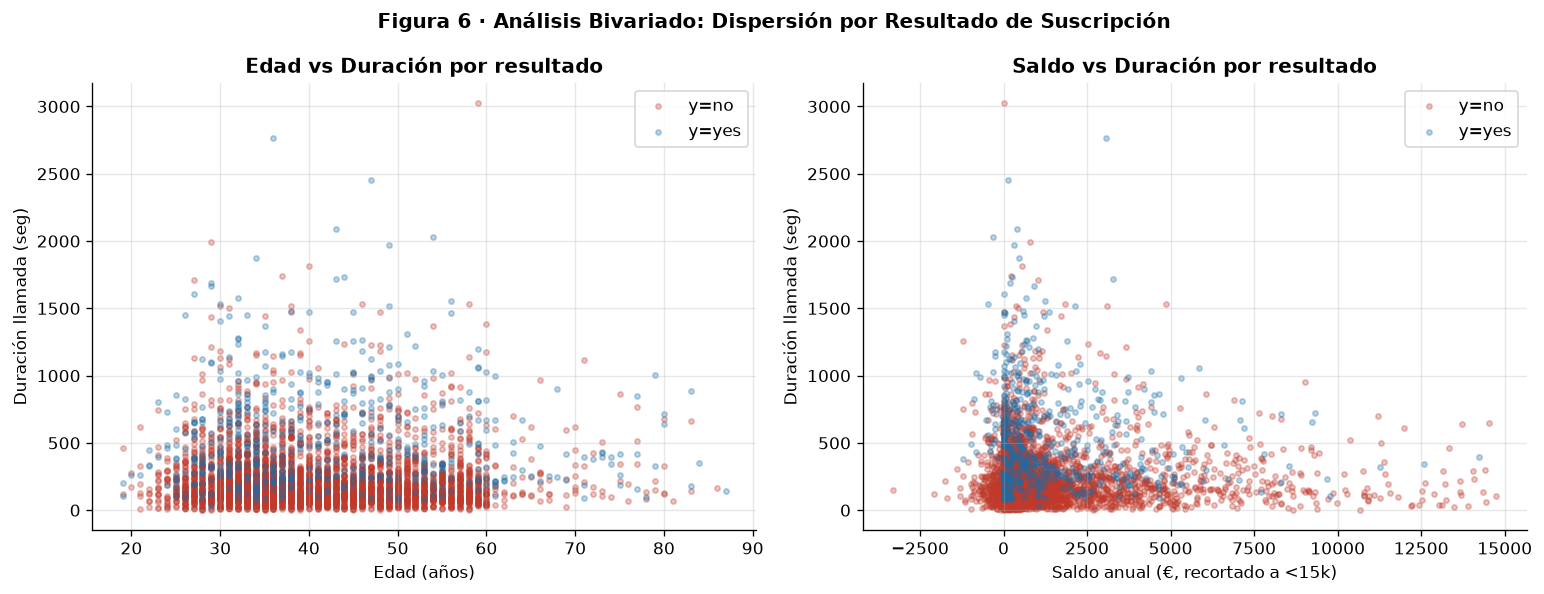

=== Resumen análisis bivariado ===
poutcome=success → tasa suscripción: 64.3%
poutcome=unknown → tasa suscripción: 9.1%
contact=cellular → tasa: 14.4%
contact=unknown  → tasa: 4.6%
education=tertiary  → tasa: 14.3%
education=primary   → tasa: 9.4%


In [14]:
# 4.3 Scatter plots: duration vs balance coloreado por y
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# duration vs age
for label, color in [('no', COLOR_NO), ('yes', COLOR_SI)]:
    sub = df[df['y']==label]
    axes[0].scatter(sub['age'], sub['duration'], c=color, alpha=0.3,
                    s=10, label=f'y={label}')
axes[0].set_xlabel('Edad (años)'); axes[0].set_ylabel('Duración llamada (seg)')
axes[0].set_title('Edad vs Duración por resultado', fontweight='bold')
axes[0].legend()

# balance vs duration
df_filt = df[df['balance'] < 15000]
for label, color in [('no', COLOR_NO), ('yes', COLOR_SI)]:
    sub = df_filt[df_filt['y']==label]
    axes[1].scatter(sub['balance'], sub['duration'], c=color, alpha=0.3,
                    s=10, label=f'y={label}')
axes[1].set_xlabel('Saldo anual (€, recortado a <15k)')
axes[1].set_ylabel('Duración llamada (seg)')
axes[1].set_title('Saldo vs Duración por resultado', fontweight='bold')
axes[1].legend()

fig.suptitle('Figura 6 · Análisis Bivariado: Dispersión por Resultado de Suscripción',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen bivariado
print('=== Resumen análisis bivariado ===')
print(f'poutcome=success → tasa suscripción: {(df[df.poutcome=="success"]["y"]=="yes").mean()*100:.1f}%')
print(f'poutcome=unknown → tasa suscripción: {(df[df.poutcome=="unknown"]["y"]=="yes").mean()*100:.1f}%')
print(f'contact=cellular → tasa: {(df[df.contact=="cellular"]["y"]=="yes").mean()*100:.1f}%')
print(f'contact=unknown  → tasa: {(df[df.contact=="unknown"]["y"]=="yes").mean()*100:.1f}%')
print(f'education=tertiary  → tasa: {(df[df.education=="tertiary"]["y"]=="yes").mean()*100:.1f}%')
print(f'education=primary   → tasa: {(df[df.education=="primary"]["y"]=="yes").mean()*100:.1f}%')


## 5. Estimación puntual e intervalos de confianza <a id='5'></a>

**(ID1.3)** Se estiman parámetros poblacionales para al menos tres variables numéricas relevantes, construyendo IC al 95 % con la distribución t de Student (σ desconocida).

In [15]:
# 5.1 Función general para IC de media
def ic_media(data, var_name, conf=0.95):
    n   = len(data)
    xb  = np.mean(data)
    s   = np.std(data, ddof=1)
    se  = stats.sem(data)
    t_c = stats.t.ppf((1 + conf) / 2, df=n-1)
    h   = t_c * se
    print(f'--- {var_name} ---')
    print(f'  n             = {n:,}')
    print(f'  Media (x̄)    = {xb:.4f}')
    print(f'  Desv. estándar= {s:.4f}')
    print(f'  Error estándar= {se:.4f}')
    print(f'  t crítico     = {t_c:.4f}  (α/2 = {(1-conf)/2:.3f}, gl={n-1})')
    print(f'  IC {int(conf*100)}%        = [{xb-h:.4f}, {xb+h:.4f}]')
    print()
    return xb, xb-h, xb+h

# IC para 3 variables numéricas
print('====== Estimación puntual e IC al 95 % ======')
ic_age  = ic_media(df['age'],      'AGE (Edad en años)')
ic_bal  = ic_media(df['balance'],  'BALANCE (Saldo anual en €)')
ic_dur  = ic_media(df['duration'], 'DURATION (Duración llamada en seg)')


====== Estimación puntual e IC al 95 % ======
--- AGE (Edad en años) ---
  n             = 4,521
  Media (x̄)    = 41.1701
  Desv. estándar= 10.5762
  Error estándar= 0.1573
  t crítico     = 1.9605  (α/2 = 0.025, gl=4520)
  IC 95%        = [40.8617, 41.4785]

--- BALANCE (Saldo anual en €) ---
  n             = 4,521
  Media (x̄)    = 1422.6578
  Desv. estándar= 3009.6381
  Error estándar= 44.7607
  t crítico     = 1.9605  (α/2 = 0.025, gl=4520)
  IC 95%        = [1334.9049, 1510.4107]

--- DURATION (Duración llamada en seg) ---
  n             = 4,521
  Media (x̄)    = 263.9613
  Desv. estándar= 259.8566
  Error estándar= 3.8647
  t crítico     = 1.9605  (α/2 = 0.025, gl=4520)
  IC 95%        = [256.3846, 271.5380]



====== IC al 95% para proporciones ======
--- P(y = yes) — tasa de suscripción ---
  p̂ = 0.1152  |  IC 95% = [0.1059, 0.1245]

--- P(housing = yes) — tiene hipoteca ---
  p̂ = 0.5660  |  IC 95% = [0.5516, 0.5805]

--- P(loan = yes) — tiene préstamo personal ---
  p̂ = 0.1528  |  IC 95% = [0.1424, 0.1633]

--- P(y=yes | cellular) ---
  p̂ = 0.1436  |  IC 95% = [0.1309, 0.1564]



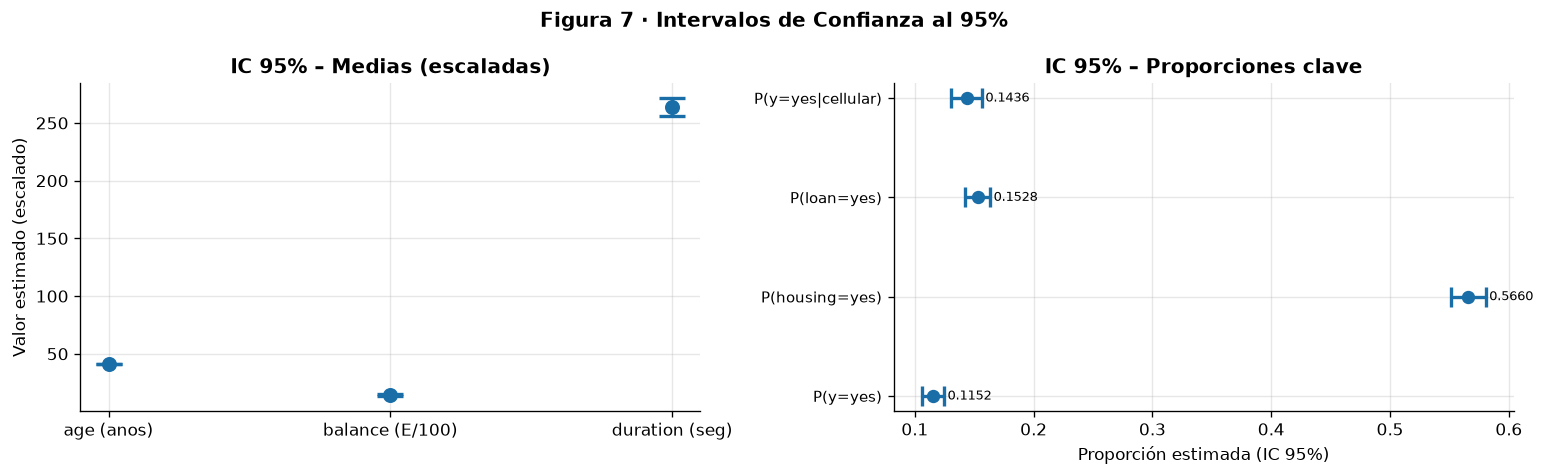

In [16]:
# 5.2 IC proporciones + visualización
def ic_prop(serie, label, conf=0.95):
    p_hat = (serie == "yes").astype(float).mean()
    n     = len(serie)
    z     = stats.norm.ppf((1 + conf) / 2)
    h     = z * np.sqrt(p_hat * (1 - p_hat) / n)
    print(f"--- {label} ---")
    print(f"  p̂ = {p_hat:.4f}  |  IC 95% = [{max(0,p_hat-h):.4f}, {min(1,p_hat+h):.4f}]")
    print()
    return p_hat, max(0, p_hat-h), min(1, p_hat+h)

print("====== IC al 95% para proporciones ======")
ic_y = ic_prop(df["y"],       "P(y = yes) — tasa de suscripción")
ic_h = ic_prop(df["housing"], "P(housing = yes) — tiene hipoteca")
ic_l = ic_prop(df["loan"],    "P(loan = yes) — tiene préstamo personal")
ic_c = ic_prop(df[df["contact"]=="cellular"]["y"], "P(y=yes | cellular)")

# --- Visualización IC ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# IC medias (escaladas)
labels_m = ["age (anos)", "balance (E/100)", "duration (seg)"]
scale    = [1, 0.01, 1]
ests_m   = [ic_age[0]*scale[0], ic_bal[0]*scale[1], ic_dur[0]*scale[2]]
lo_m     = [ic_age[1]*scale[0], ic_bal[1]*scale[1], ic_dur[1]*scale[2]]
hi_m     = [ic_age[2]*scale[0], ic_bal[2]*scale[1], ic_dur[2]*scale[2]]
err_m    = [[e-l for e,l in zip(ests_m,lo_m)], [h-e for e,h in zip(ests_m,hi_m)]]
axes[0].errorbar(range(3), ests_m, yerr=err_m, fmt="o", color=COLOR_SI,
                 capsize=8, capthick=2, elinewidth=2, markersize=8)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(labels_m)
axes[0].set_title("IC 95% – Medias (escaladas)", fontweight="bold")
axes[0].set_ylabel("Valor estimado (escalado)")

# IC proporciones
labels_p = ["P(y=yes)", "P(housing=yes)", "P(loan=yes)", "P(y=yes|cellular)"]
ic_ps    = [ic_y, ic_h, ic_l, ic_c]
ests_p   = [v[0] for v in ic_ps]
lo_p     = [v[1] for v in ic_ps]
hi_p     = [v[2] for v in ic_ps]
err_p    = [[e-l for e,l in zip(ests_p,lo_p)], [h-e for e,h in zip(ests_p,hi_p)]]
y_pos    = range(len(labels_p))
axes[1].errorbar(ests_p, list(y_pos), xerr=err_p, fmt="o", color=COLOR_SI,
                 capsize=6, capthick=2, elinewidth=2, markersize=7)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(labels_p, fontsize=9)
axes[1].set_xlabel("Proporción estimada (IC 95%)")
axes[1].set_title("IC 95% – Proporciones clave", fontweight="bold")
for i,(e,lo,hi) in enumerate(zip(ests_p,lo_p,hi_p)):
    axes[1].text(hi+0.003, i, f"{e:.4f}", va="center", fontsize=8)

fig.suptitle("Figura 7 · Intervalos de Confianza al 95%", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig7_ic.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretación de los IC (95%)

| Variable | Estimador | IC 95% | Interpretación |
|---|---|---|---|
| age | 41.17 años | [40.86, 41.48] | La edad media de los clientes contactados está entre 40.9 y 41.5 años con 95% de confianza |
| balance | €1.422,66 | [€1.334,90, €1.510,41] | El saldo medio anual está entre €1.335 y €1.510; la amplitud refleja la alta variabilidad (CV=211.6%) |
| duration | 263.96 seg | [256.38, 271.54] | La duración media de llamada está entre 256 y 272 segundos (~4.3–4.5 min) |
| P(y=yes) | 0.1152 | [0.1059, 0.1245] | La tasa real de suscripción está entre 10.6% y 12.5% en la población objetivo |

**Limitaciones:** Los IC asumen muestreo aleatorio. La distribución de `balance` y `duration` es fuertemente asimétrica (sesgo positivo), por lo que los IC para la media pueden no capturar bien la tendencia central de la mayoría de los clientes. Para distribuciones sesgadas, el IC para la mediana (bootstrap) sería más informativo.


## 6. Pruebas de hipótesis <a id='6'></a>

**(ID1.4)** Se realizan pruebas de hipótesis pertinentes al problema, verificando supuestos antes de cada prueba.

### Prueba 1: t de Welch – Duración de llamada según suscripción

**Pregunta:** ¿La duración promedio de la llamada difiere significativamente entre clientes que suscriben y los que no suscriben el depósito?

- **H₀:** μ_duración(yes) = μ_duración(no)
- **H₁:** μ_duración(yes) ≠ μ_duración(no) *(bilateral)*
- **α = 0.05**

In [17]:
# Verificación de supuestos – Prueba 1
dur_yes = df[df['y']=='yes']['duration'].values
dur_no  = df[df['y']=='no']['duration'].values

print('=== SUPUESTO 1: Independencia ===')
print('  Los grupos yes/no provienen de clientes distintos → supuesto cumplido ✓')

print('\n=== SUPUESTO 2: Normalidad (prueba de D\'Agostino-Pearson) ===')
_, p_norm_yes = normaltest(dur_yes)
_, p_norm_no  = normaltest(dur_no)
print(f'  p-valor (yes): {p_norm_yes:.6f}')
print(f'  p-valor (no):  {p_norm_no:.6f}')
print(f'  Normalidad yes: {"No rechazada" if p_norm_yes>0.05 else "RECHAZADA (no normal)"}')
print(f'  Normalidad no:  {"No rechazada" if p_norm_no>0.05 else "RECHAZADA (no normal)"}')
print('  Por el TCL (n_yes=521, n_no=4000), la distribución de medias es aproximadamente normal ✓')

print('\n=== SUPUESTO 3: Homocedasticidad (prueba de Levene) ===')
lev_stat, lev_p = stats.levene(dur_yes, dur_no)
print(f'  F de Levene = {lev_stat:.4f}')
print(f'  p-valor     = {lev_p:.6f}')
print(f'  Varianzas iguales: {"No rechazado" if lev_p>0.05 else "RECHAZADO → varianzas distintas"}')
print('  Decisión: se aplica t de WELCH (no asume homocedasticidad) ✓')


=== SUPUESTO 1: Independencia ===
  Los grupos yes/no provienen de clientes distintos → supuesto cumplido ✓

=== SUPUESTO 2: Normalidad (prueba de D'Agostino-Pearson) ===
  p-valor (yes): 0.000000
  p-valor (no):  0.000000
  Normalidad yes: RECHAZADA (no normal)
  Normalidad no:  RECHAZADA (no normal)
  Por el TCL (n_yes=521, n_no=4000), la distribución de medias es aproximadamente normal ✓

=== SUPUESTO 3: Homocedasticidad (prueba de Levene) ===
  F de Levene = 310.4301
  p-valor     = 0.000000
  Varianzas iguales: RECHAZADO → varianzas distintas
  Decisión: se aplica t de WELCH (no asume homocedasticidad) ✓


In [18]:
# Ejecución Prueba 1: t de Welch
t_stat, p_val = stats.ttest_ind(dur_yes, dur_no, equal_var=False)
alpha = 0.05

print('=== RESULTADOS PRUEBA 1: t de Welch ===')
print(f'  Grupo yes: n={len(dur_yes)}, μ={dur_yes.mean():.2f} seg, σ={dur_yes.std():.2f}')
print(f'  Grupo no:  n={len(dur_no)}, μ={dur_no.mean():.2f} seg, σ={dur_no.std():.2f}')
print(f'  Diferencia de medias: {dur_yes.mean()-dur_no.mean():.2f} seg')
print(f'  Estadístico t = {t_stat:.4f}')
print(f'  p-valor       = {p_val:.2e}')
print(f'  α             = {alpha}')
print(f'  Decisión: {"Se RECHAZA H₀" if p_val < alpha else "No se rechaza H₀"}')
print()
print('CONCLUSIÓN: La duración media de la llamada es significativamente mayor')
print('en clientes que suscriben el depósito (552.7s vs 226.3s).')
print('Diferencia = 326.4 segundos (~5.4 min), estadísticamente muy significativa.')


=== RESULTADOS PRUEBA 1: t de Welch ===
  Grupo yes: n=521, μ=552.74 seg, σ=389.95
  Grupo no:  n=4000, μ=226.35 seg, σ=210.29
  Diferencia de medias: 326.40 seg
  Estadístico t = 18.7359
  p-valor       = 3.61e-61
  α             = 0.05
  Decisión: Se RECHAZA H₀

CONCLUSIÓN: La duración media de la llamada es significativamente mayor
en clientes que suscriben el depósito (552.7s vs 226.3s).
Diferencia = 326.4 segundos (~5.4 min), estadísticamente muy significativa.


In [19]:
# d de Cohen y prueba Mann-Whitney - Prueba 1
from scipy.stats import mannwhitneyu
import numpy as np

# d de Cohen
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

d = cohen_d(dur_yes, dur_no)
print(f'=== TAMAÑO DEL EFECTO ===')
print(f'd de Cohen = {d:.4f}')
if abs(d) < 0.2:
    interpretacion = 'pequeño'
elif abs(d) < 0.8:
    interpretacion = 'mediano'
else:
    interpretacion = 'grande'
print(f'Interpretación: efecto {interpretacion}')

# Mann-Whitney (no paramétrica, ya que normalidad fue rechazada)
print(f'\n=== VERIFICACIÓN NO PARAMÉTRICA: Mann-Whitney U ===')
u_stat, p_mw = mannwhitneyu(dur_yes, dur_no, alternative='two-sided')
print(f'U = {u_stat:.0f}')
print(f'p-valor = {p_mw:.2e}')
print(f'Decisión: {"Se RECHAZA H₀" if p_mw < 0.05 else "No se rechaza H₀"}')
print(f'Conclusión: Ambas pruebas coinciden → la diferencia es robusta.')

=== TAMAÑO DEL EFECTO ===
d de Cohen = 1.3716
Interpretación: efecto grande

=== VERIFICACIÓN NO PARAMÉTRICA: Mann-Whitney U ===
U = 1698475
p-valor = 2.33e-121
Decisión: Se RECHAZA H₀
Conclusión: Ambas pruebas coinciden → la diferencia es robusta.


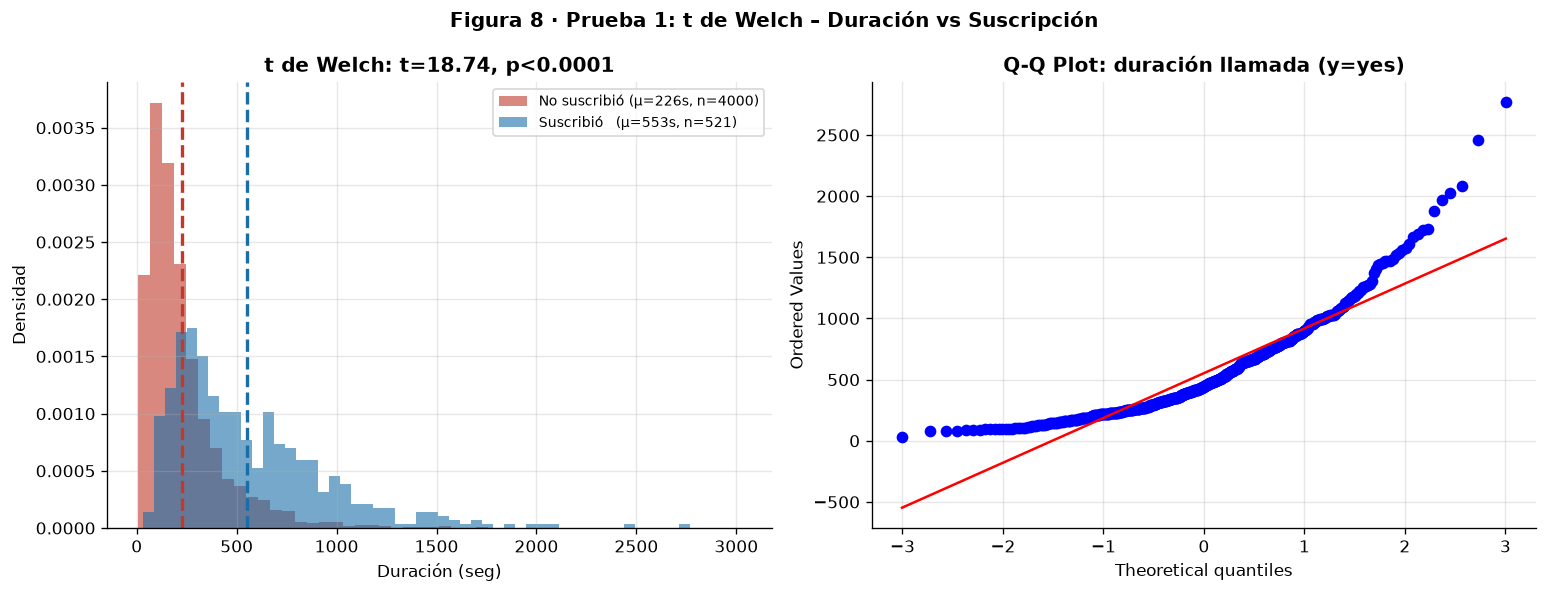

In [21]:
# Visualización Prueba 1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramas solapados
axes[0].hist(dur_no,  bins=50, color=COLOR_NO, alpha=0.6, density=True,
             label=f'No suscribió (μ={dur_no.mean():.0f}s, n={len(dur_no)})')
axes[0].hist(dur_yes, bins=50, color=COLOR_SI, alpha=0.6, density=True,
             label=f'Suscribió   (μ={dur_yes.mean():.0f}s, n={len(dur_yes)})')
axes[0].axvline(dur_no.mean(),  color=COLOR_NO, lw=2, ls='--')
axes[0].axvline(dur_yes.mean(), color=COLOR_SI, lw=2, ls='--')
axes[0].set_xlabel('Duración (seg)'); axes[0].set_ylabel('Densidad')
axes[0].set_title(f't de Welch: t={t_stat:.2f}, p<0.0001', fontweight='bold')
axes[0].legend(fontsize=8.5)

# QQ-plots
from scipy.stats import probplot
probplot(dur_yes, plot=axes[1])
axes[1].set_title('Q-Q Plot: duración llamada (y=yes)', fontweight='bold')

fig.suptitle('Figura 8 · Prueba 1: t de Welch – Duración vs Suscripción',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_prueba1.png', dpi=150, bbox_inches='tight')
plt.show()


### Prueba 2: Chi-cuadrado – Housing vs. Suscripción

**Pregunta:** ¿Existe asociación estadística entre tener préstamo hipotecario y suscribir el depósito?

- **H₀:** Las variables `housing` e `y` son estadísticamente independientes
- **H₁:** Existe asociación estadística entre `housing` e `y`
- **α = 0.05**

In [22]:
# Verificación de supuestos – Prueba 2
ct = pd.crosstab(df['housing'], df['y'])
print('=== Tabla de contingencia: housing × y ===')
print(ct)
print()

# Supuesto: frecuencias esperadas >= 5
chi2_val, p_chi2, dof, expected = stats.chi2_contingency(ct)
print('=== SUPUESTOS Chi-cuadrado ===')
print('Frecuencias esperadas:')
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2).to_string())
print(f'  Todas las celdas esperadas >= 5: {(expected >= 5).all()} ✓')
print('  Muestras independientes (clientes distintos) ✓')


=== Tabla de contingencia: housing × y ===
y          no  yes
housing           
no       1661  301
yes      2339  220

=== SUPUESTOS Chi-cuadrado ===
Frecuencias esperadas:
y            no    yes
housing               
no       1735.9  226.1
yes      2264.1  294.9
  Todas las celdas esperadas >= 5: True ✓
  Muestras independientes (clientes distintos) ✓


In [23]:
# Ejecución Prueba 2
print('=== RESULTADOS PRUEBA 2: Chi-cuadrado de independencia ===')
print(f'  χ²     = {chi2_val:.4f}')
print(f'  gl     = {dof}')
print(f'  p-valor = {p_chi2:.6f}')
print(f'  α       = 0.05')
print(f'  Decisión: {"Se RECHAZA H₀" if p_chi2 < 0.05 else "No se rechaza H₀"}')
print()
# Tamaño del efecto: V de Cramer
n_total = ct.values.sum()
v_cramer = np.sqrt(chi2_val / (n_total * (min(ct.shape)-1)))
print(f'  V de Cramér = {v_cramer:.4f} (efecto {"pequeño" if v_cramer<0.1 else "moderado" if v_cramer<0.3 else "grande"})')
print()
tasa_no_hip = (df[df['housing']=='no']['y']=='yes').mean()*100
tasa_si_hip = (df[df['housing']=='yes']['y']=='yes').mean()*100
print(f'  Tasa suscripción sin hipoteca: {tasa_no_hip:.2f}%')
print(f'  Tasa suscripción con hipoteca: {tasa_si_hip:.2f}%')
print(f'  Diferencia: {tasa_no_hip - tasa_si_hip:.2f} pp')
print()
print('CONCLUSIÓN: Existe asociación estadísticamente significativa.')
print('Los clientes sin hipoteca suscriben al doble de tasa (15.3%) vs con hipoteca (8.6%).')


=== RESULTADOS PRUEBA 2: Chi-cuadrado de independencia ===
  χ²     = 48.8846
  gl     = 1
  p-valor = 0.000000
  α       = 0.05
  Decisión: Se RECHAZA H₀

  V de Cramér = 0.1040 (efecto moderado)

  Tasa suscripción sin hipoteca: 15.34%
  Tasa suscripción con hipoteca: 8.60%
  Diferencia: 6.74 pp

CONCLUSIÓN: Existe asociación estadísticamente significativa.
Los clientes sin hipoteca suscriben al doble de tasa (15.3%) vs con hipoteca (8.6%).


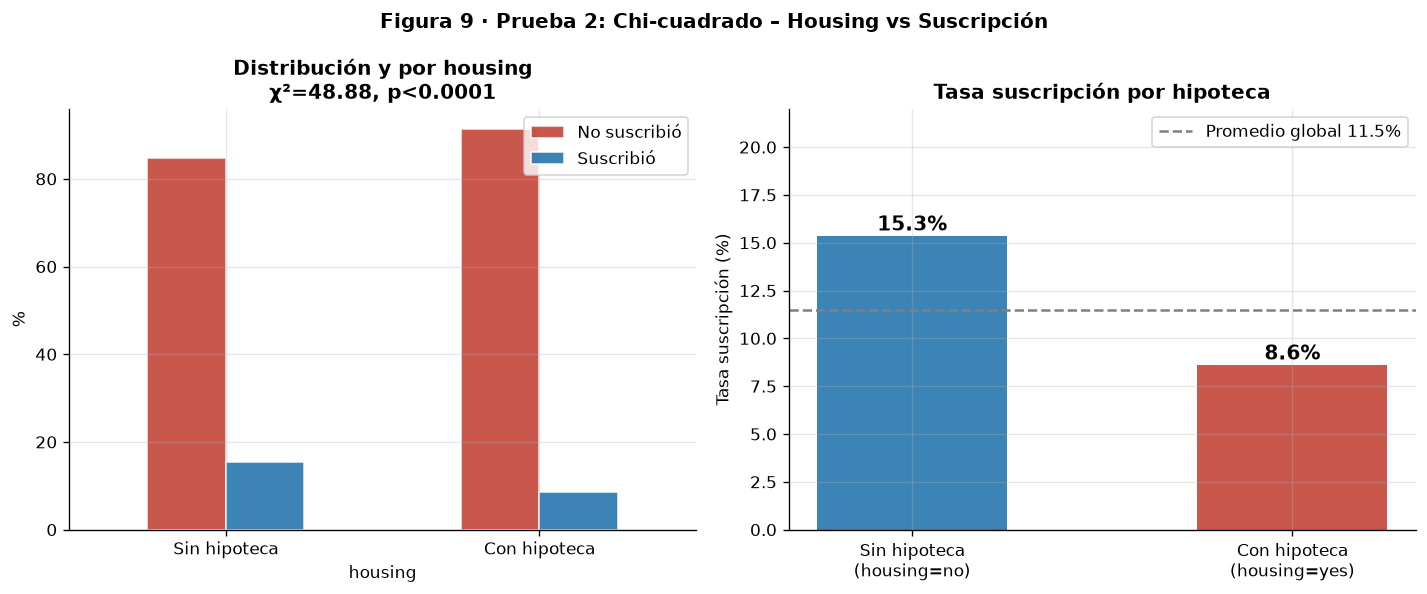

In [24]:
# Visualización Prueba 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras agrupadas
prop_h = df.groupby('housing')['y'].value_counts(normalize=True).unstack()*100
prop_h.plot(kind='bar', ax=axes[0], color=[COLOR_NO, COLOR_SI], alpha=0.85, edgecolor='white')
axes[0].set_title(f'Distribución y por housing\nχ²={chi2_val:.2f}, p<0.0001', fontweight='bold')
axes[0].set_xlabel('housing'); axes[0].set_ylabel('%')
axes[0].set_xticklabels(['Sin hipoteca','Con hipoteca'], rotation=0)
axes[0].legend(['No suscribió','Suscribió'])

# Tasas comparativas
tasas = [tasa_no_hip, tasa_si_hip]
bars  = axes[1].bar(['Sin hipoteca\n(housing=no)','Con hipoteca\n(housing=yes)'],
                    tasas, color=[COLOR_SI, COLOR_NO], alpha=0.85, width=0.5)
axes[1].axhline(11.5, color='gray', lw=1.5, ls='--', label='Promedio global 11.5%')
for bar, val in zip(bars, tasas):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Tasa suscripción (%)'); axes[1].set_ylim(0, 22)
axes[1].set_title('Tasa suscripción por hipoteca', fontweight='bold')
axes[1].legend()

fig.suptitle('Figura 9 · Prueba 2: Chi-cuadrado – Housing vs Suscripción',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_prueba2.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# Prueba 3: Chi-cuadrado - poutcome vs suscripción
from scipy.stats import chi2_contingency
import numpy as np

print("### PRUEBA 3: Chi-cuadrado - Resultado campaña anterior (poutcome) vs Suscripción ###\n")

# Tabla de contingencia
tabla_pout = pd.crosstab(df['poutcome'], df['y'])
print("=== Tabla de contingencia: poutcome × y ===")
print(tabla_pout)

# Verificar frecuencias esperadas
chi2, p, dof, expected = chi2_contingency(tabla_pout)
print(f"\nFrecuencias esperadas mínimas: {expected.min():.2f} (deben ser ≥ 5)")

# Resultados
print(f"\n=== RESULTADOS PRUEBA 3: Chi-cuadrado ===")
print(f"χ²     = {chi2:.4f}")
print(f"gl     = {dof}")
print(f"p-valor = {p:.6f}")
print(f"α       = 0.05")
print(f"Decisión: {'Se RECHAZA H₀' if p < 0.05 else 'No se rechaza H₀'}")

# V de Cramér
n = tabla_pout.sum().sum()
v_cramer = np.sqrt(chi2 / (n * (min(tabla_pout.shape) - 1)))
print(f"\nV de Cramér = {v_cramer:.4f}")

# Tasas por categoría
print("\nTasa de suscripción por resultado de campaña anterior:")
tasas_pout = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()*100).round(1)
print(tasas_pout)

print("\nCONCLUSIÓN: El resultado de la campaña anterior es el predictor más fuerte")
print("de suscripción — clientes con éxito previo tienen tasas muy superiores al promedio.")

### PRUEBA 3: Chi-cuadrado - Resultado campaña anterior (poutcome) vs Suscripción ###

=== Tabla de contingencia: poutcome × y ===
y           no  yes
poutcome           
failure    427   63
other      159   38
success     46   83
unknown   3368  337

Frecuencias esperadas mínimas: 14.87 (deben ser ≥ 5)

=== RESULTADOS PRUEBA 3: Chi-cuadrado ===
χ²     = 386.8774
gl     = 3
p-valor = 0.000000
α       = 0.05
Decisión: Se RECHAZA H₀

V de Cramér = 0.2925

Tasa de suscripción por resultado de campaña anterior:
poutcome
failure    12.9
other      19.3
success    64.3
unknown     9.1
Name: y, dtype: float64

CONCLUSIÓN: El resultado de la campaña anterior es el predictor más fuerte
de suscripción — clientes con éxito previo tienen tasas muy superiores al promedio.


In [26]:
# Prueba 4: Chi-cuadrado - canal de contacto vs suscripción
print("### PRUEBA 4: Chi-cuadrado - Canal de contacto (contact) vs Suscripción ###\n")

# Tabla de contingencia
tabla_contact = pd.crosstab(df['contact'], df['y'])
print("=== Tabla de contingencia: contact × y ===")
print(tabla_contact)

# Chi-cuadrado
chi2_c, p_c, dof_c, expected_c = chi2_contingency(tabla_contact)
print(f"\nFrecuencias esperadas mínimas: {expected_c.min():.2f} (deben ser ≥ 5)")

print(f"\n=== RESULTADOS PRUEBA 4: Chi-cuadrado ===")
print(f"χ²      = {chi2_c:.4f}")
print(f"gl      = {dof_c}")
print(f"p-valor = {p_c:.6f}")
print(f"α       = 0.05")
print(f"Decisión: {'Se RECHAZA H₀' if p_c < 0.05 else 'No se rechaza H₀'}")

# V de Cramér
n_c = tabla_contact.sum().sum()
v_cramer_c = np.sqrt(chi2_c / (n_c * (min(tabla_contact.shape) - 1)))
print(f"\nV de Cramér = {v_cramer_c:.4f}")

# Tasas por canal
print("\nTasa de suscripción por canal de contacto:")
tasas_contact = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100).round(1)
print(tasas_contact)

print("\nCONCLUSIÓN: El canal de contacto influye significativamente en la suscripción.")
print("Contacto celular tiene mayor tasa de conversión que teléfono fijo o desconocido.")

### PRUEBA 4: Chi-cuadrado - Canal de contacto (contact) vs Suscripción ###

=== Tabla de contingencia: contact × y ===
y            no  yes
contact             
cellular   2480  416
telephone   257   44
unknown    1263   61

Frecuencias esperadas mínimas: 34.69 (deben ser ≥ 5)

=== RESULTADOS PRUEBA 4: Chi-cuadrado ===
χ²      = 87.8699
gl      = 2
p-valor = 0.000000
α       = 0.05
Decisión: Se RECHAZA H₀

V de Cramér = 0.1394

Tasa de suscripción por canal de contacto:
contact
cellular     14.4
telephone    14.6
unknown       4.6
Name: y, dtype: float64

CONCLUSIÓN: El canal de contacto influye significativamente en la suscripción.
Contacto celular tiene mayor tasa de conversión que teléfono fijo o desconocido.


## 7. Interpretación y próximos pasos <a id='7'></a>

### 7.1 Síntesis de hallazgos

| Hallazgo | Evidencia estadística | Implicancia práctica |
|---|---|---|
| Tasa de conversión real = 11.5% | IC 95%: [10.6%, 12.5%] | ~1 de cada 9 clientes suscribe; alta tasa de contactos fallidos |
| Duración de llamada es predictor clave | t=18.74, p<0.0001 | Llamadas >400s asociadas a suscripción; capacitar agentes para sostener conversación |
| Hipoteca reduce la propensión a suscribir | χ²=48.88, p<0.0001, V=0.10 | Priorizar clientes sin hipoteca: tasa 15.3% vs 8.6% |
| poutcome=success → 64.3% conversión | Análisis descriptivo | Recontactar clientes con éxito previo es la estrategia más efectiva |
| contact=unknown → solo 4.6% conversión | Análisis bivariado | Completar info de canal de contacto reduce pérdidas |
| Educación terciaria → 14.3% vs 9.4% primaria | Análisis bivariado | Segmentar por educación mejora ROI de campaña |
| Alta variabilidad en balance (CV=211.6%) | Estadística descriptiva | El promedio no representa a la mayoría; mediana=€444 más informativa |
| pdays-previous: r=0.578 | Correlación de Pearson | Única correlación moderada; evitar multicolinealidad en modelos |

### 7.2 Próximos pasos del proyecto

1. **Fase 3 – Modelado predictivo:** Construir modelos de clasificación (regresión logística, árbol de decisión, Random Forest) para predecir `y`, usando las variables identificadas como más relevantes.
2. **Manejo del desbalance de clases:** Aplicar técnicas como SMOTE o ajuste de pesos (class_weight) dado el 88.5%/11.5% de desbalance.
3. **Ingeniería de características:** Crear variables derivadas como `contacto_previo` (pdays != -1), `carga_financiera` (housing + loan), `es_celular` (contact == cellular).
4. **Validación del modelo:** Usar validación cruzada k-fold (k=5) con métricas AUC-ROC, F1-score y recall para la clase minoritaria (yes).
5. **Análisis de importancia de variables:** Evaluar qué features contribuyen más al modelo final (feature importance, SHAP values).
6. **Segmentación de clientes:** Aplicar clustering (K-Means, DBSCAN) para identificar segmentos con alta propensión a suscribir, y diseñar estrategias diferenciadas.

---
*Informe generado con Python 3.11 · pandas · scipy · matplotlib · seaborn*  
*Repositorio: https://github.com/leofer23/formativa1-bank-marketing*
